# Import Libraries

In [1]:
#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import random as rd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer

# Helping Functions

In [2]:
def systematic_sample(df, size):
    length = len(df)
    interval = length // size
    rd.seed(None)
    first = rd.randint(0, interval)
    indexes = np.arange(first, length, step = interval)
    return df.iloc[indexes]

In [3]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

# 1. Titanic Data Set

# Data Loading

In [4]:
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')

# Data Inspection

In [5]:
train.shape

(891, 12)

In [6]:
test.shape

(418, 11)

In [7]:
systematic_sample(train, 5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
137,138,0,1,"Futrelle, Mr. Jacques Heath",male,37.0,1,0,113803,53.1000,C123,S
315,316,1,3,"Nilsson, Miss. Helmina Josefina",female,26.0,0,0,347470,7.8542,NaN,S
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
671,672,0,1,"Davidson, Mr. Thornton",male,31.0,1,0,F.C. 12750,52.0000,B71,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.1042,C92,C


In [8]:
systematic_sample(test, 5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
17,909,3,"Assaf, Mr. Gerios",male,21.0,0,0,2692,7.2250,NaN,C
100,992,1,"Stengel, Mrs. Charles Emil Henry (Annie May Mo...",female,43.0,1,0,11778,55.4417,C116,C
183,1075,3,"Lane, Mr. Patrick",male,NaN,0,0,7935,7.7500,NaN,Q
266,1158,1,"Chisholm, Mr. Roderick Robert Crispin",male,NaN,0,0,112051,0.0000,NaN,S
349,1241,2,"Walcroft, Miss. Nellie",female,31.0,0,0,F.C.C. 13528,21.0000,NaN,S


# Checking Missing Values

In [9]:
missing_values_table(train)

Your selected dataframe has 12 columns.
There are 3 columns that have missing values.


,Missing Values,% of Total Values
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


<Axes: >

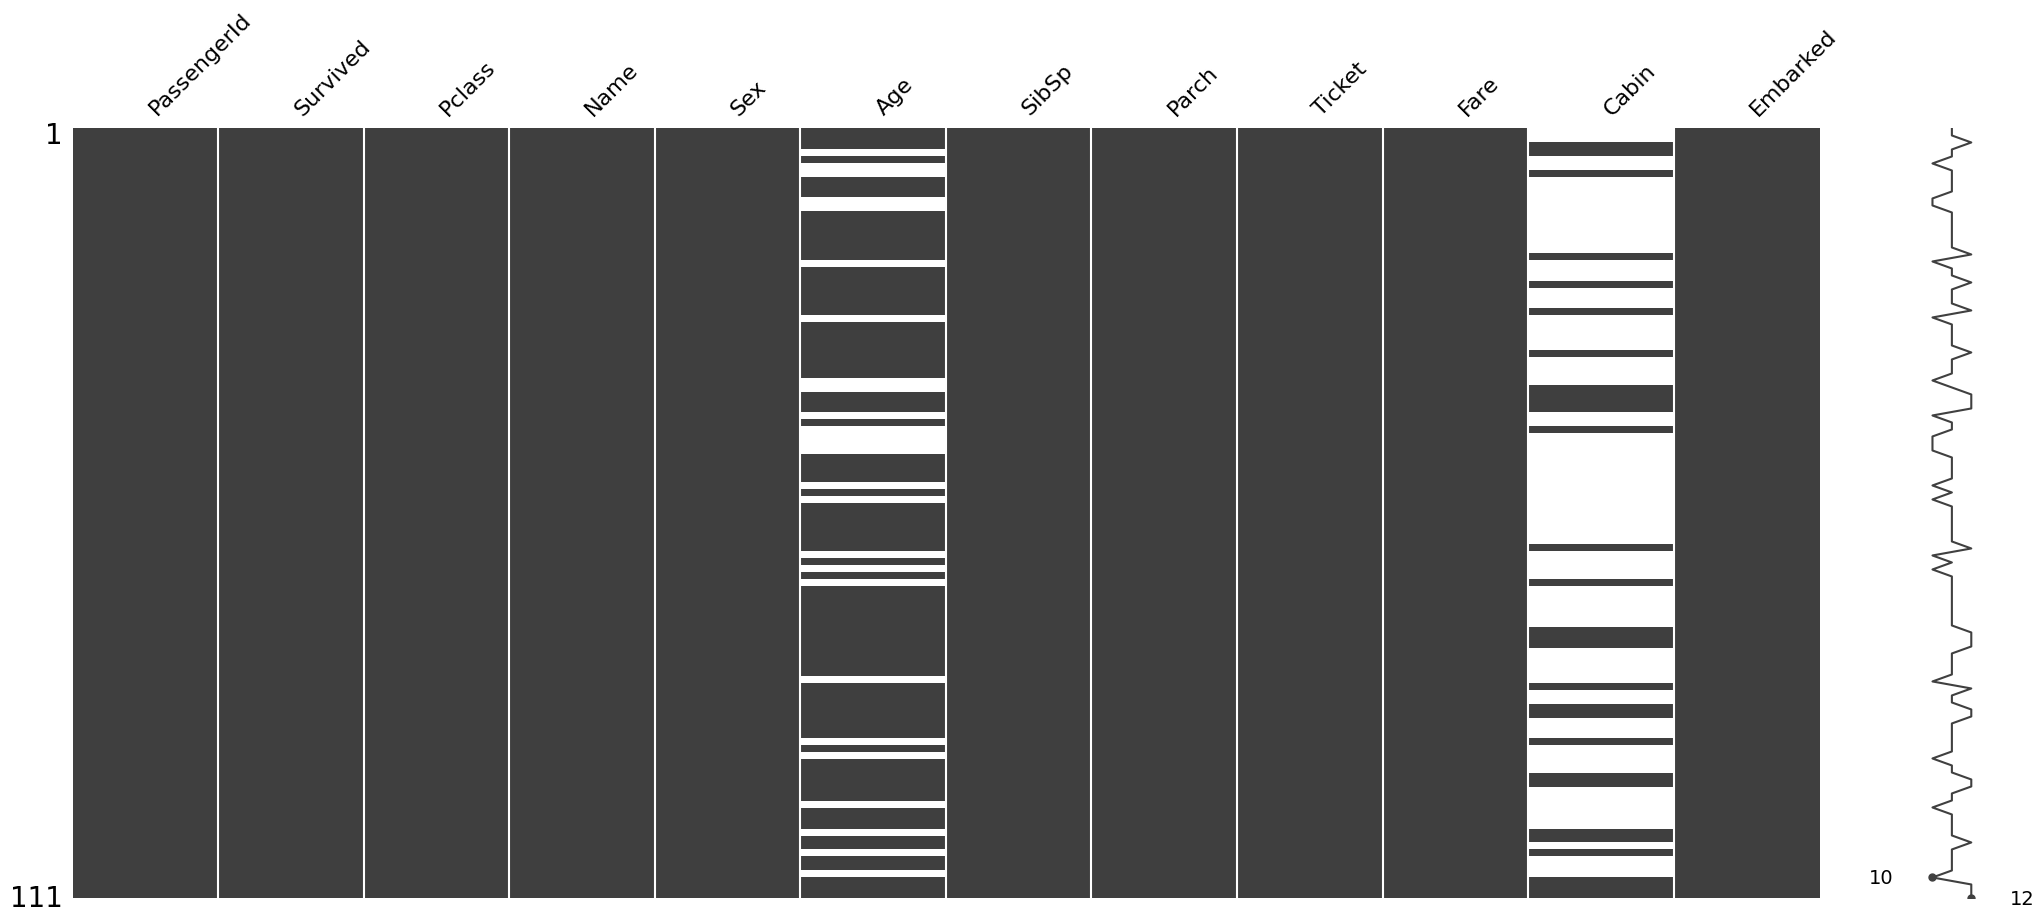

In [10]:
msno.matrix(systematic_sample(train, 100))

<Axes: >

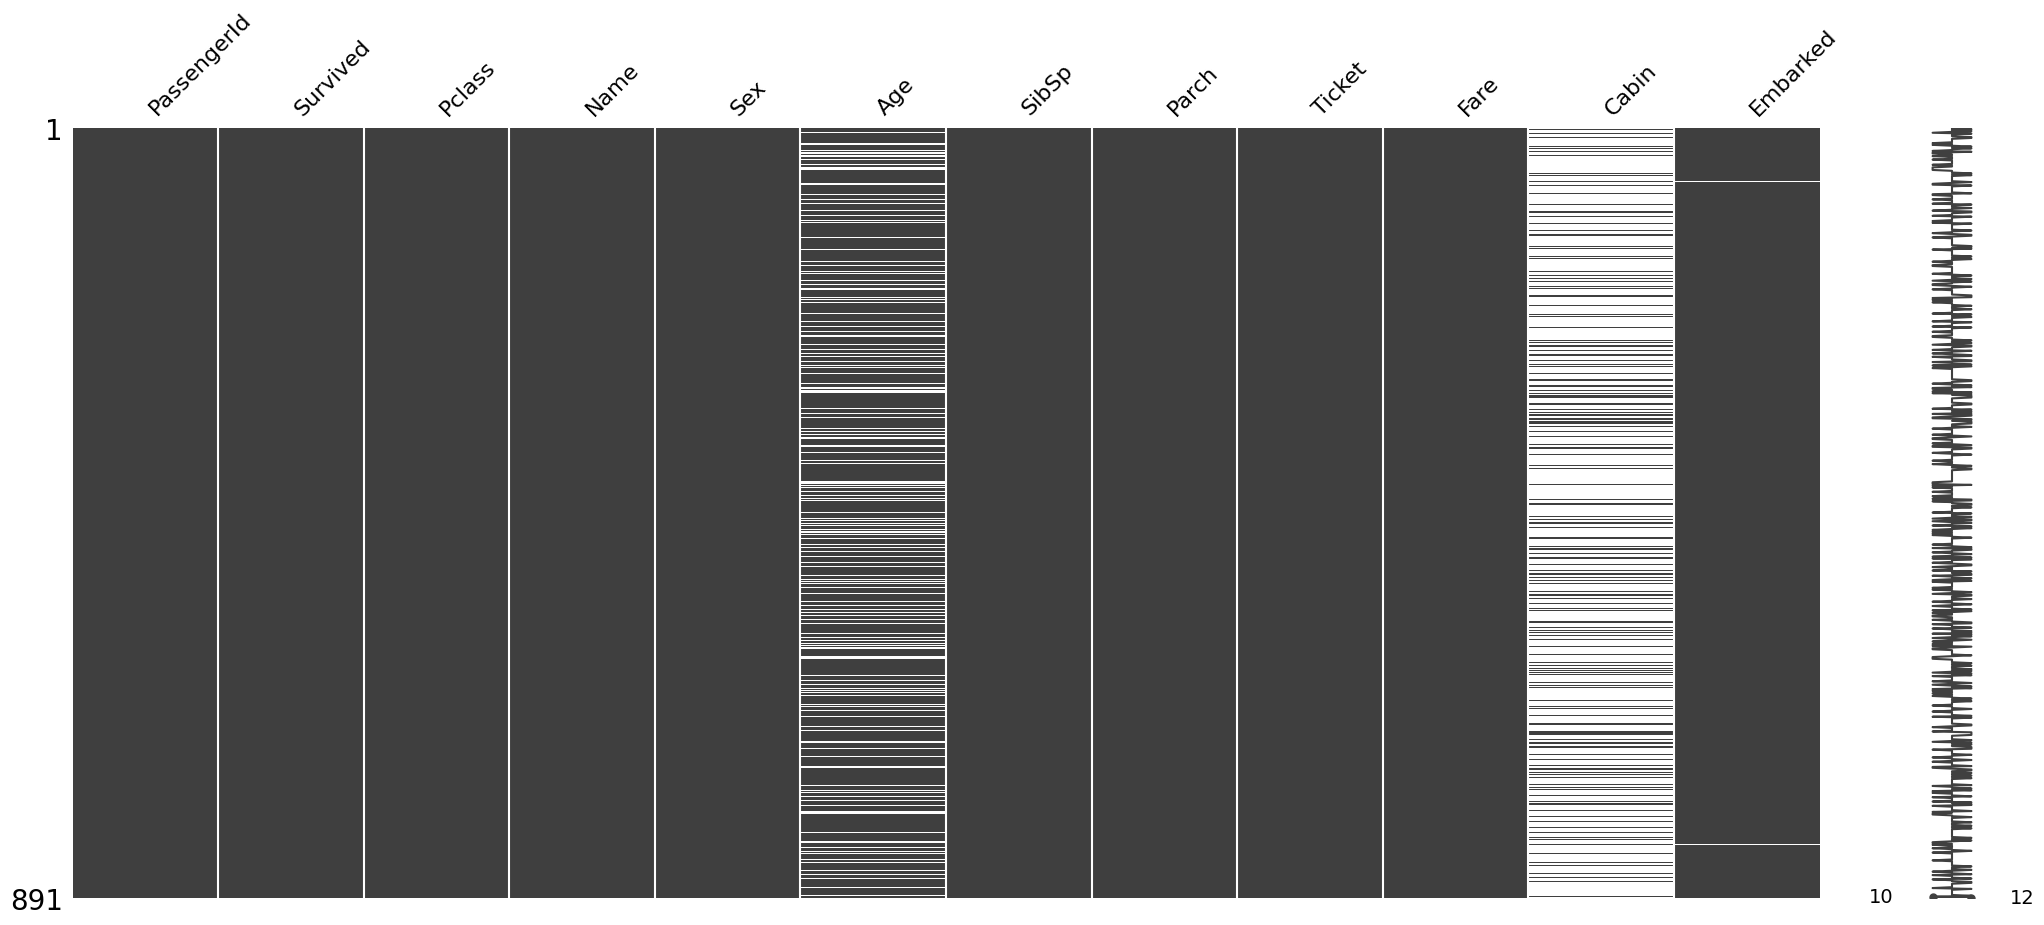

In [11]:
msno.matrix(train)

<Axes: >

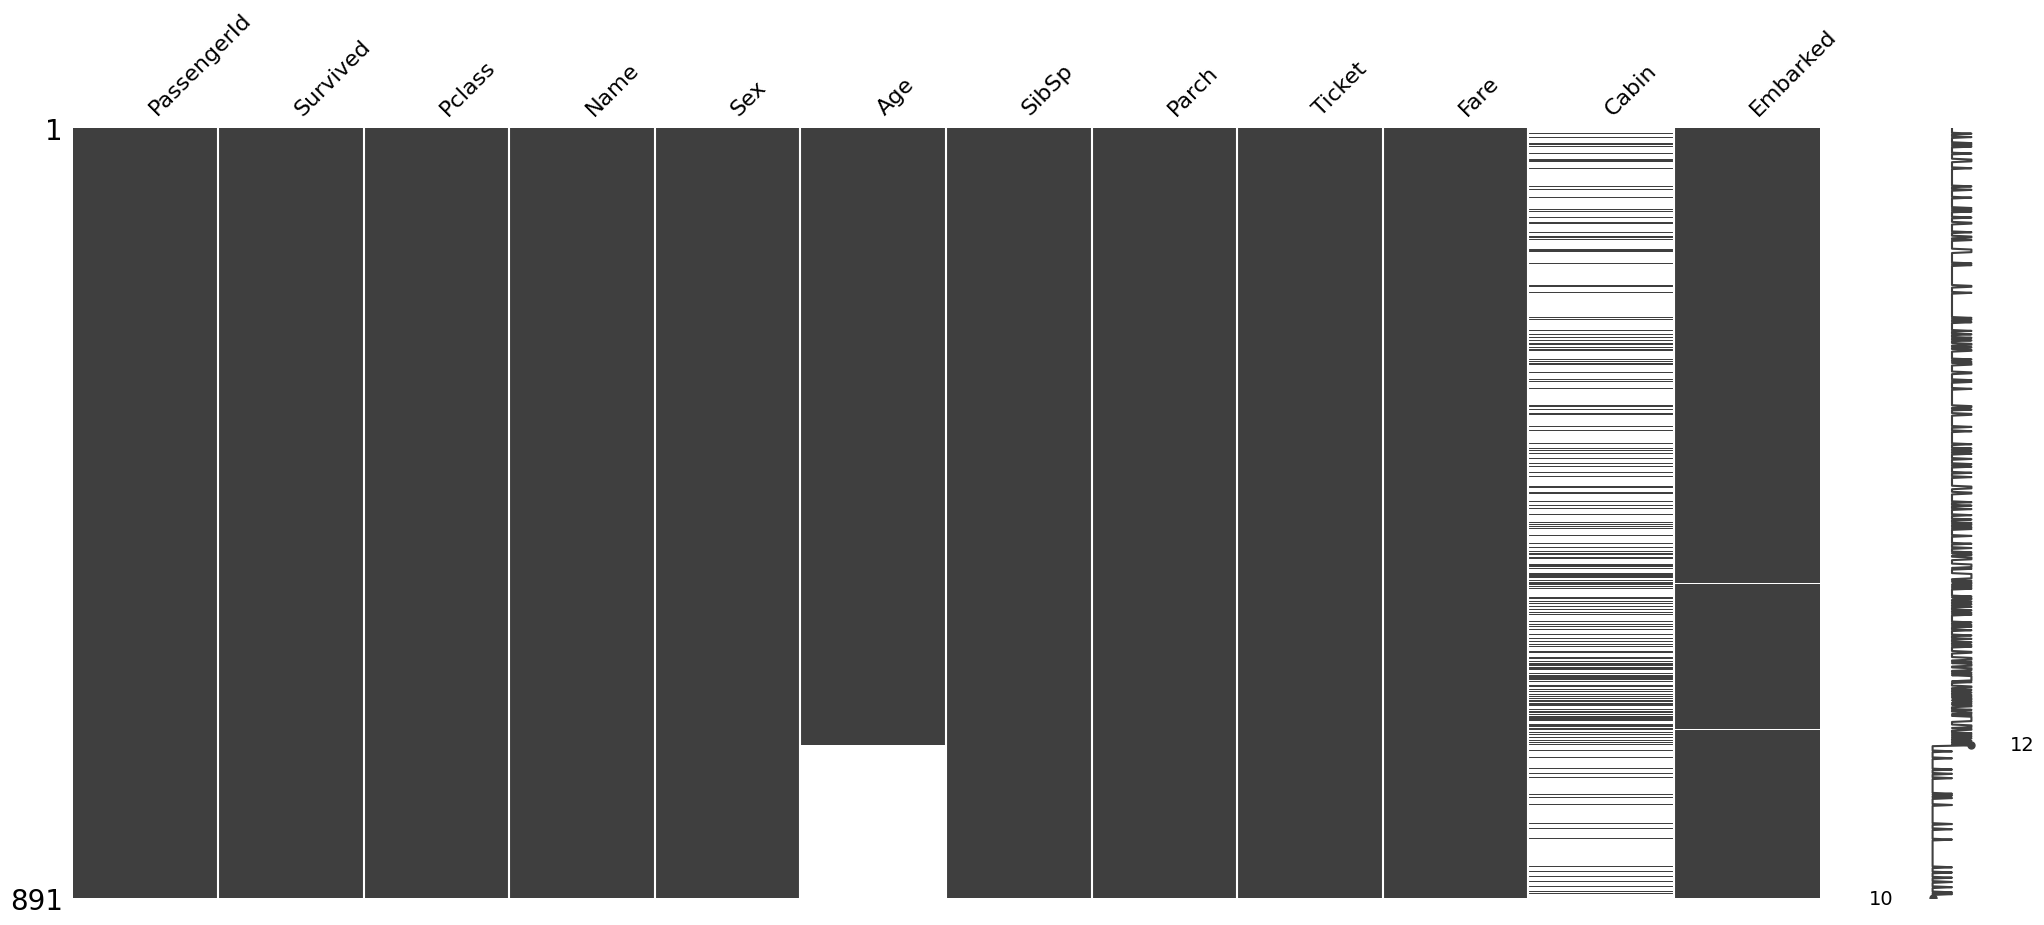

In [12]:
sorted_age = train.sort_values("Age")
msno.matrix(sorted_age)

<Axes: >

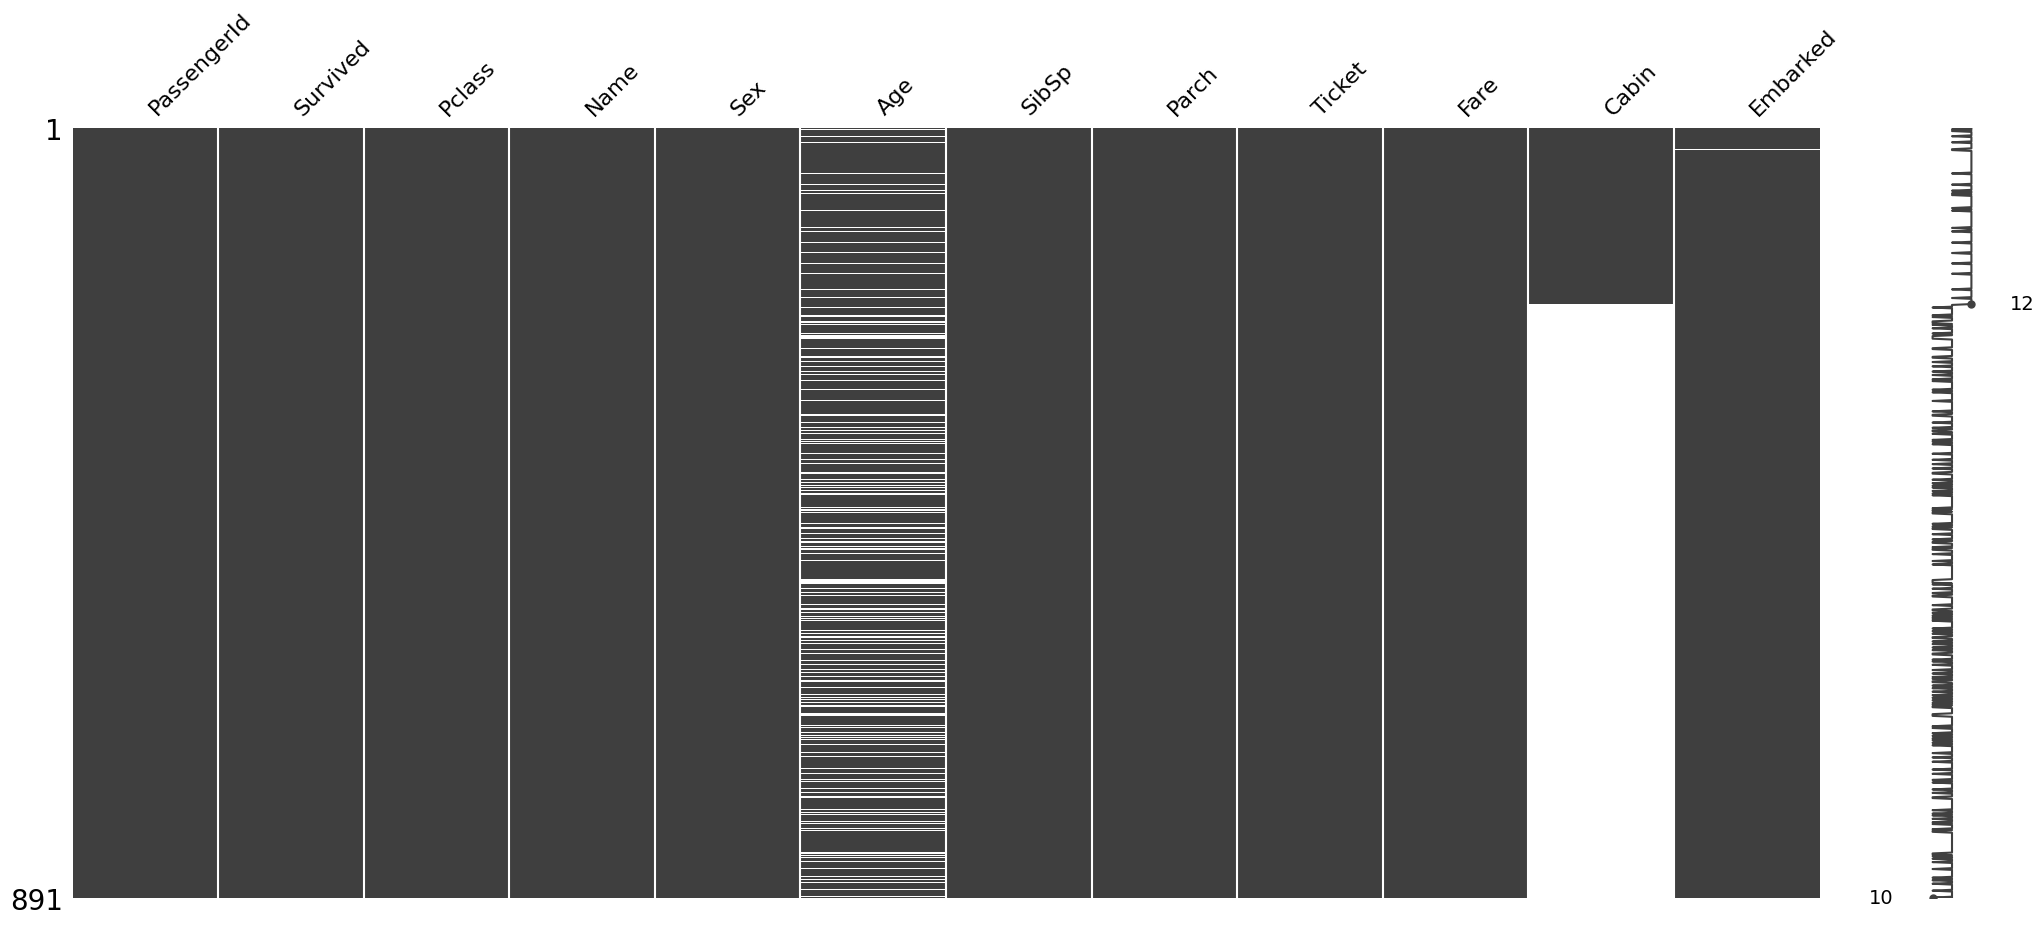

In [13]:
sorted_cabin = train.sort_values("Cabin")
msno.matrix(sorted_cabin)

<Axes: >

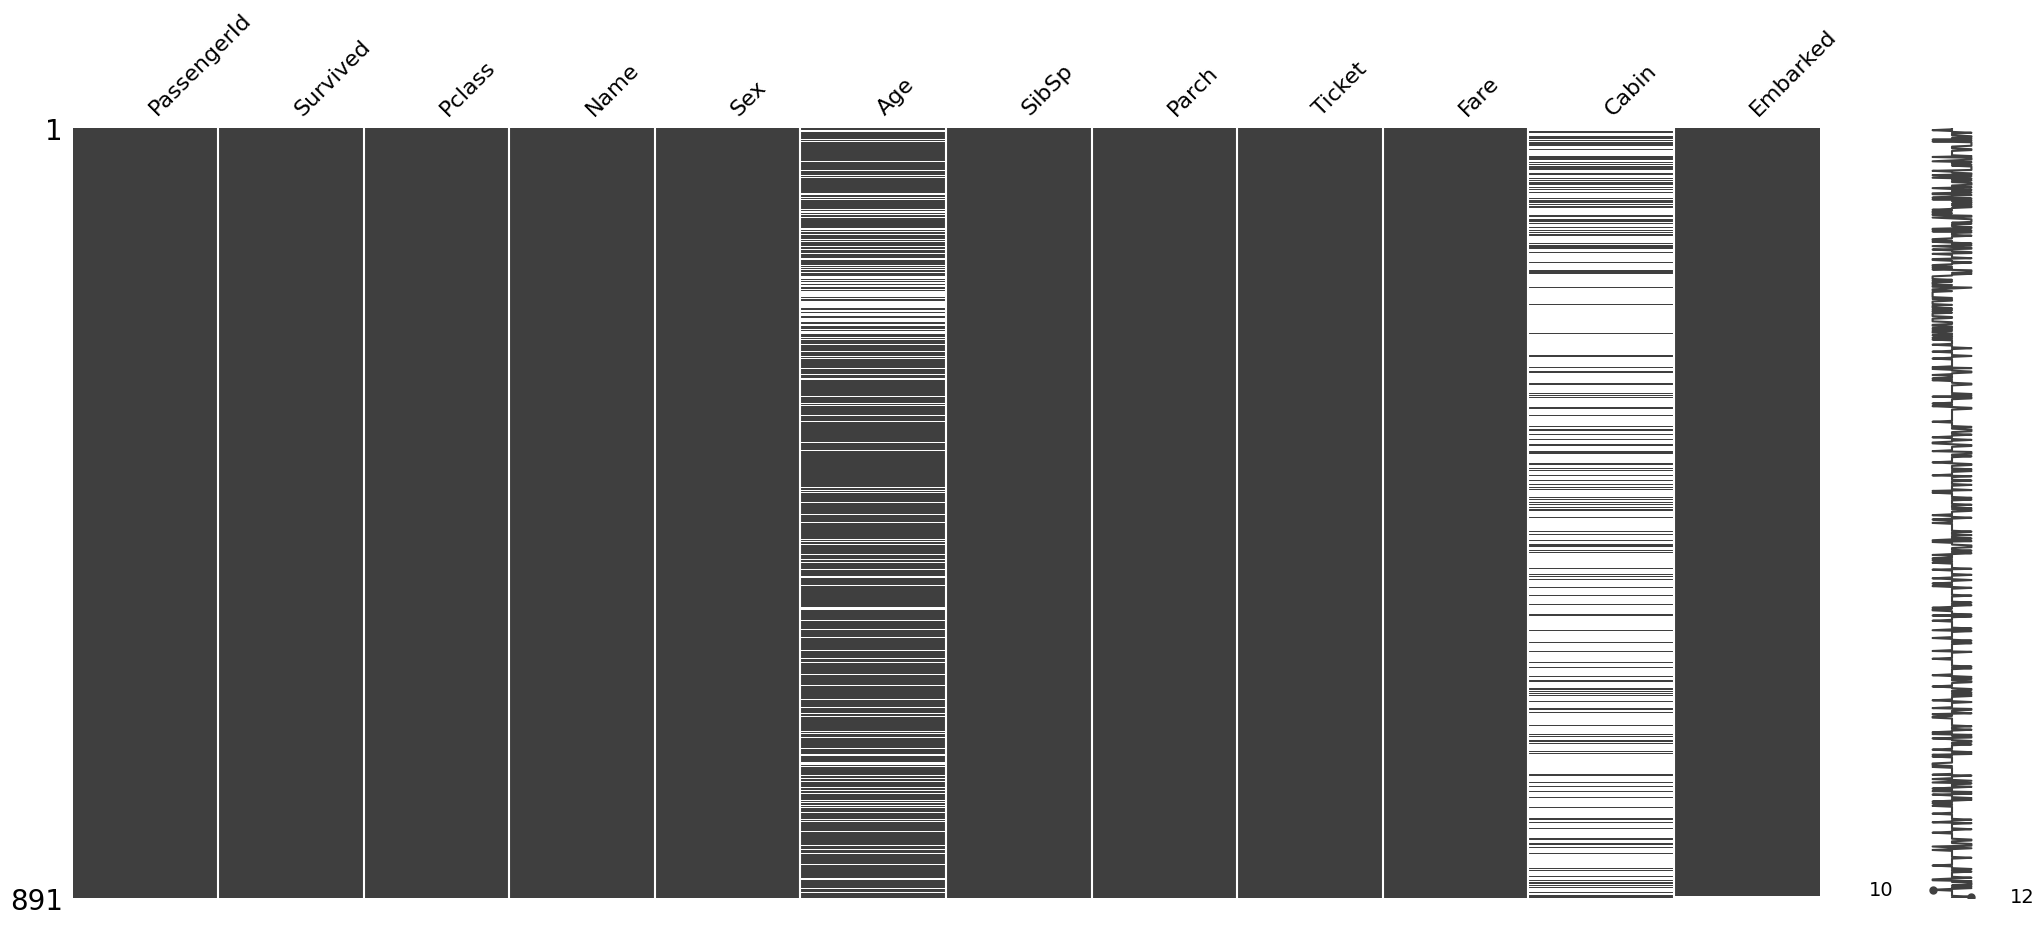

In [14]:
sorted_embarked = train.sort_values("Embarked")
msno.matrix(sorted_embarked)

# Checking the Target Column

In [15]:
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

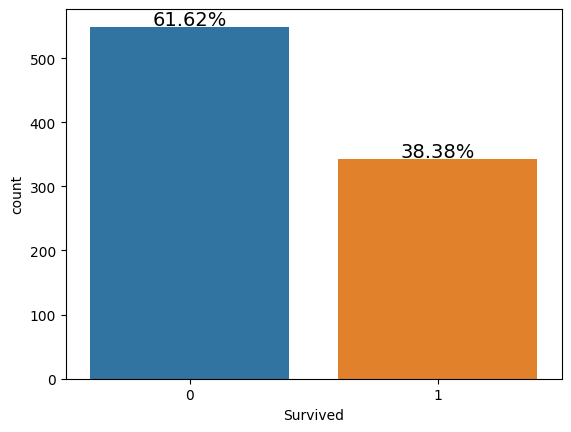

In [16]:
s = sns.countplot(x = 'Survived',data = train)
sizes=[]
for p in s.patches:
    height = p.get_height()
    sizes.append(height)
    s.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/len(train)*100),
            ha="center", fontsize=14) 

# Explicit Investigation of Missing Data

<Axes: >

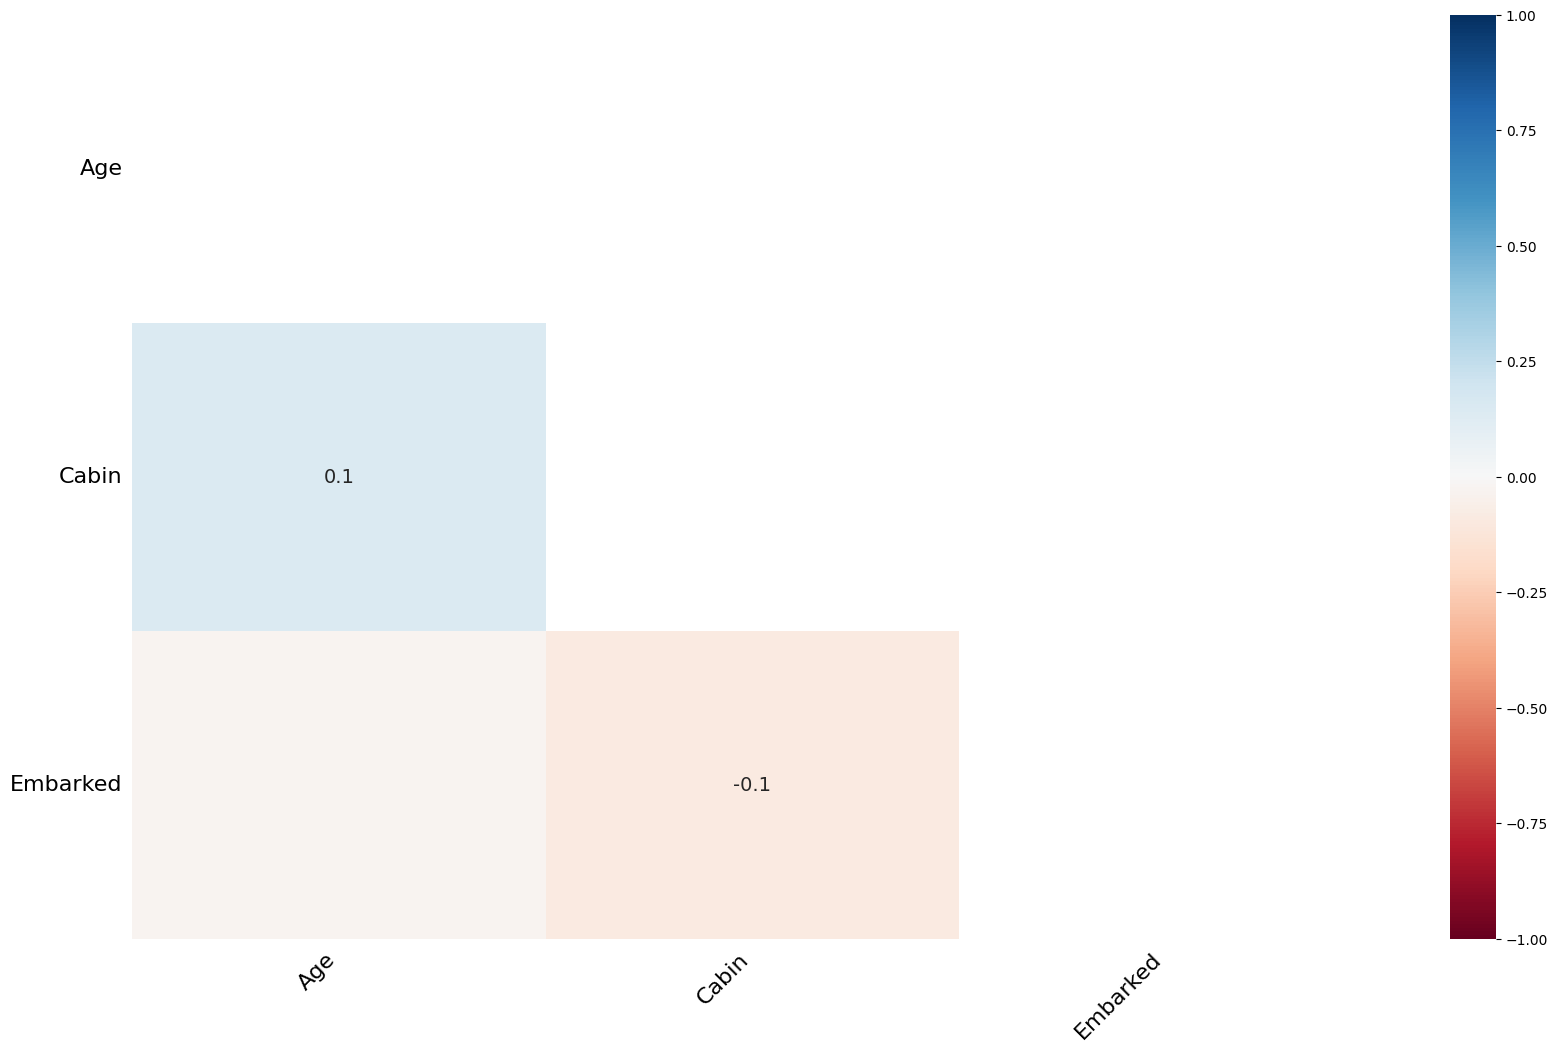

In [17]:
msno.heatmap(train)

**The heatmap function shows that there are no strong correlations between missing values of different features. This is good; low correlations further indicate that the data are MAR.**

<Axes: >

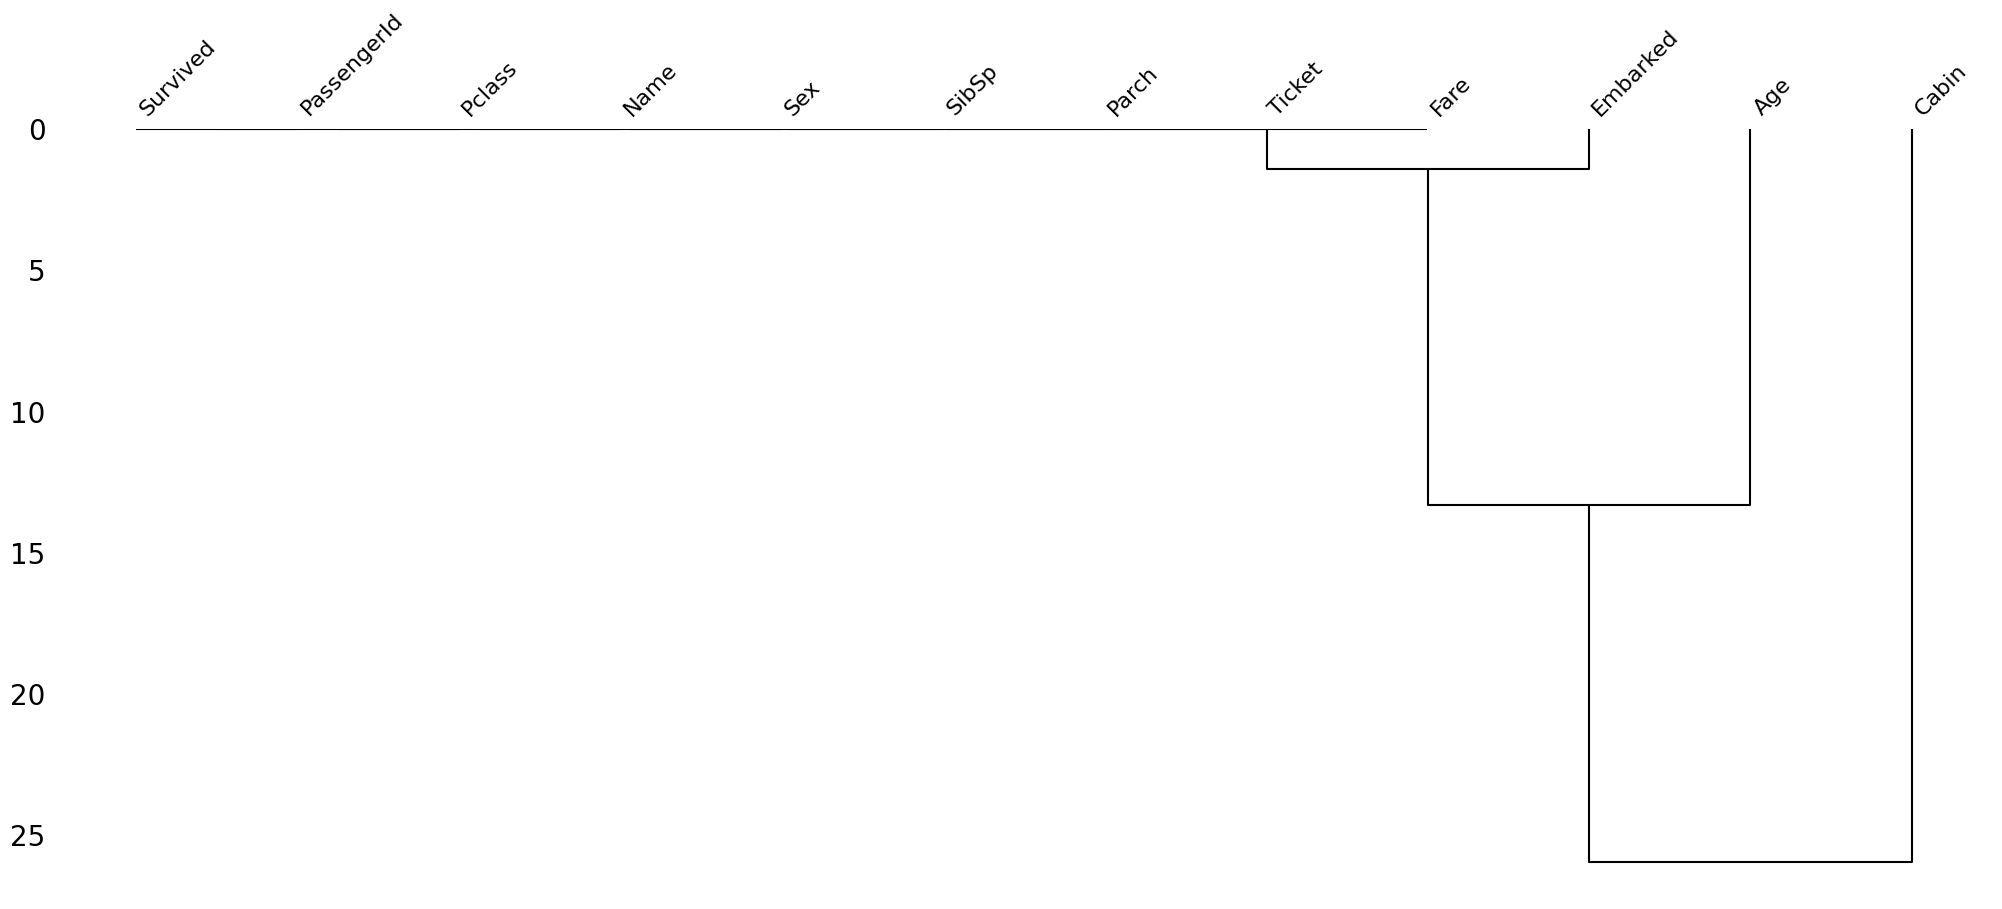

In [18]:
msno.dendrogram(train)

**Let's read the above dendrogram from a top-down perspective:**

**Cluster leaves which linked together at a distance of zero fully predict one another's presence—one variable might always be empty when another is filled, or they might always both be filled or both empty, and so on(missingno documentation)**

**the missingness of Embarked tends to be more similar to Age than to Cabin and so on.However, in this particluar case, the correlation is high since Embarked column has a very few missing values.
This dataset doesn't have much missing values but if you use the same methodology on datasets having a lot of missing values, some interesting pattern will definitely emerge.**

# Treating Missing Values

## First Approach.

In [19]:
train_1 = train.copy()
train_1['Age'].mean() #pandas skips the missing values and calculates mean of the remaining values.

29.69911764705882

In [20]:
#Drop rows which contains any NaN or missing value for Age column

train_1.dropna(subset=['Age'],how='any',inplace=True)

train_1['Age'].isnull().sum()

0

## Second Approach

In [21]:
# imputing with a constant

from sklearn.impute import SimpleImputer

train_constant = train.copy()

#setting strategy to 'constant' 

mean_imputer = SimpleImputer(strategy='constant') # imputing using constant value

train_constant.iloc[:,:] = mean_imputer.fit_transform(train_constant)

train_constant.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [22]:
from sklearn.impute import SimpleImputer
train_most_frequent = train.copy()
#setting strategy to 'mean' to impute by the mean
mean_imputer = SimpleImputer(strategy='most_frequent')# strategy can also be mean or median 
train_most_frequent.iloc[:,:] = mean_imputer.fit_transform(train_most_frequent)

In [23]:
train_most_frequent.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

# Imputations Techniques for Time Series Problems

Now let's look at ways to impute data in a typical time series problem. Tackling missing values in time Series problem is a bit different. The fillna() method is used for imputing missing values in such problems.

Basic Imputation Techniques

'ffill' or 'pad' - Replace NaN s with last observed value

'bfill' or 'backfill' - Replace NaN s with next observed value

Linear interpolation method

# Air Quality Data in India

# Data Loading

In [24]:
city_day = pd.read_csv('../input/air-quality-data-in-india/city_day.csv',parse_dates=True,index_col='Date')
city_day1 = city_day.copy(deep=True)

# Data Inspection

In [25]:
systematic_sample(city_day1, 5)

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
2018-11-21,Amritsar,93.43,147.22,19.47,28.70,46.17,6.87,0.01,5.36,14.99,5.65,1.94,7.91,140.0,Moderate
2019-11-13,Chennai,37.23,109.85,8.54,13.89,20.04,68.80,0.52,7.38,41.66,0.25,3.21,NaN,76.0,Satisfactory
2017-07-28,Hyderabad,12.62,41.75,9.44,14.04,7.70,5.12,0.17,3.60,26.67,0.10,0.96,0.71,56.0,Satisfactory
2019-04-27,Lucknow,148.62,NaN,6.07,22.33,16.51,9.63,0.88,8.43,39.02,0.19,0.88,NaN,222.0,Poor
2018-06-23,Thiruvananthapuram,17.08,44.56,3.12,13.06,9.49,2.71,0.74,5.87,27.30,NaN,NaN,NaN,53.0,Satisfactory


In [26]:
missing_values_table(city_day1)

Your selected dataframe has 15 columns.
There are 14 columns that have missing values.


,Missing Values,% of Total Values
Xylene,18109,61.3
PM10,11140,37.7
NH3,10328,35.0
Toluene,8041,27.2
Benzene,5623,19.0
AQI,4681,15.9
AQI_Bucket,4681,15.9
PM2.5,4598,15.6
NOx,4185,14.2
O3,4022,13.6


<Axes: >

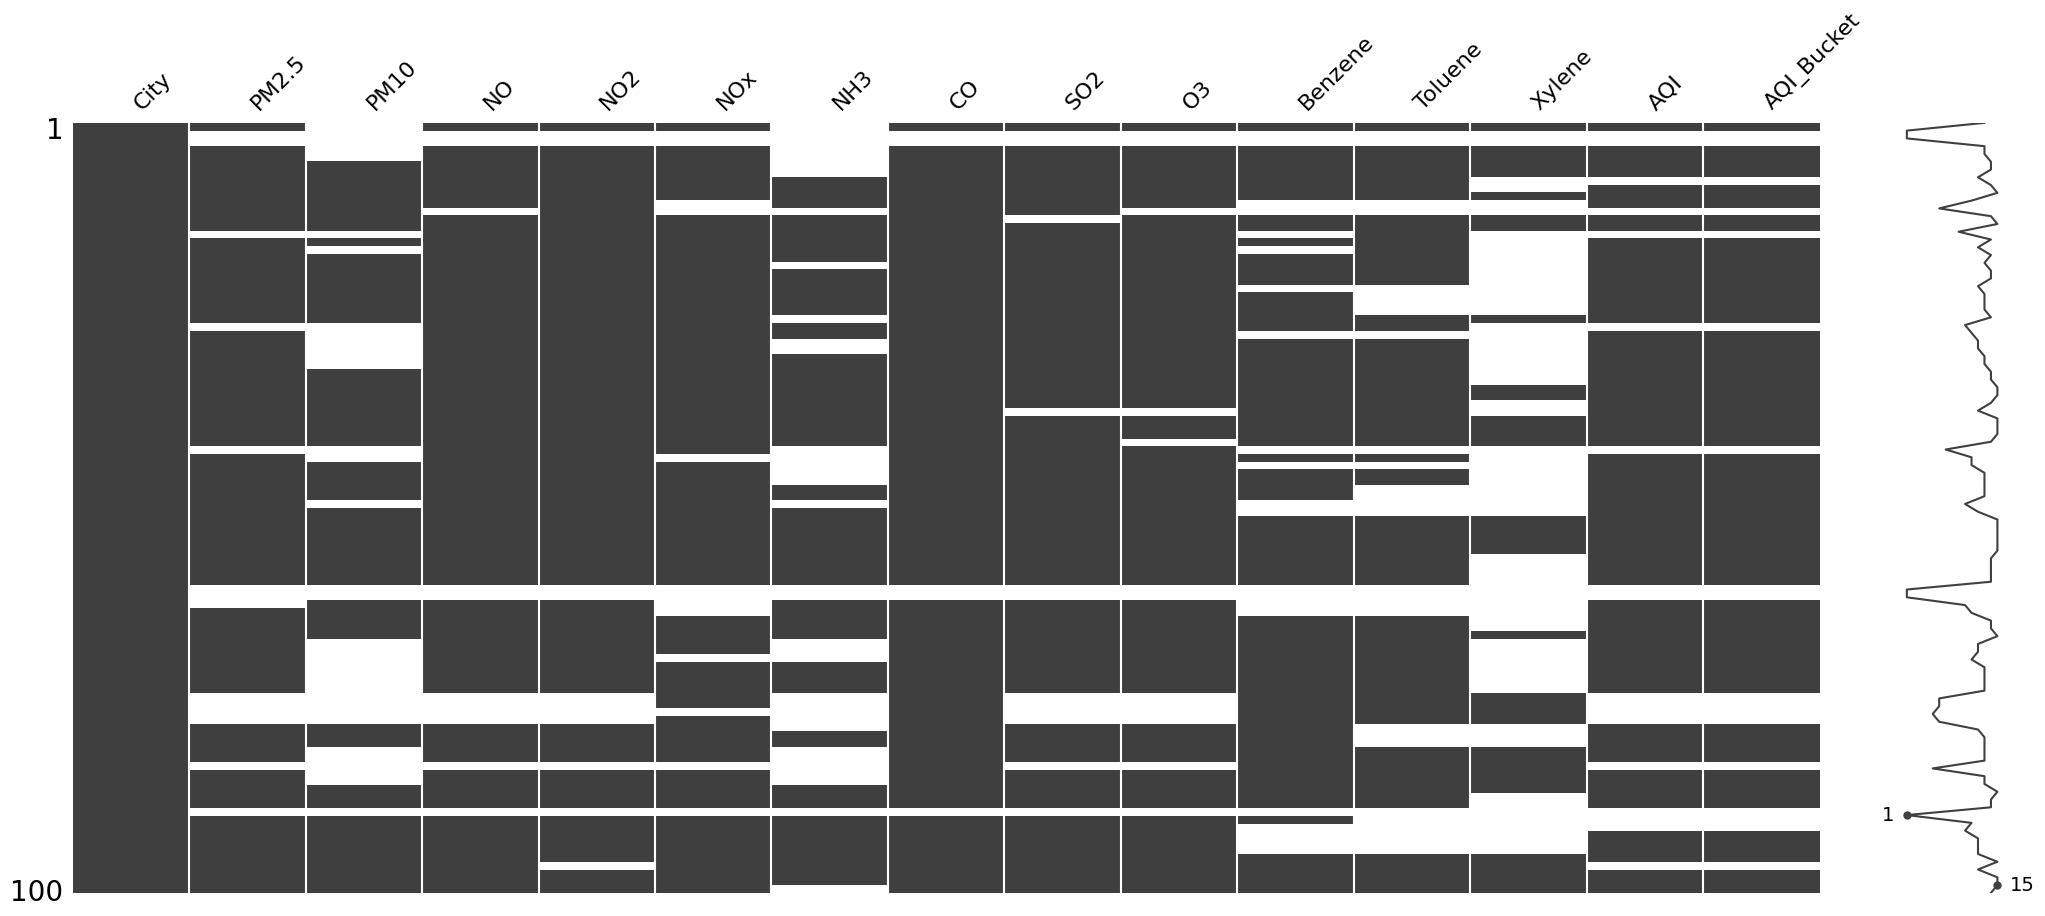

In [27]:
msno.matrix(systematic_sample(city_day1, 100))

<Axes: >

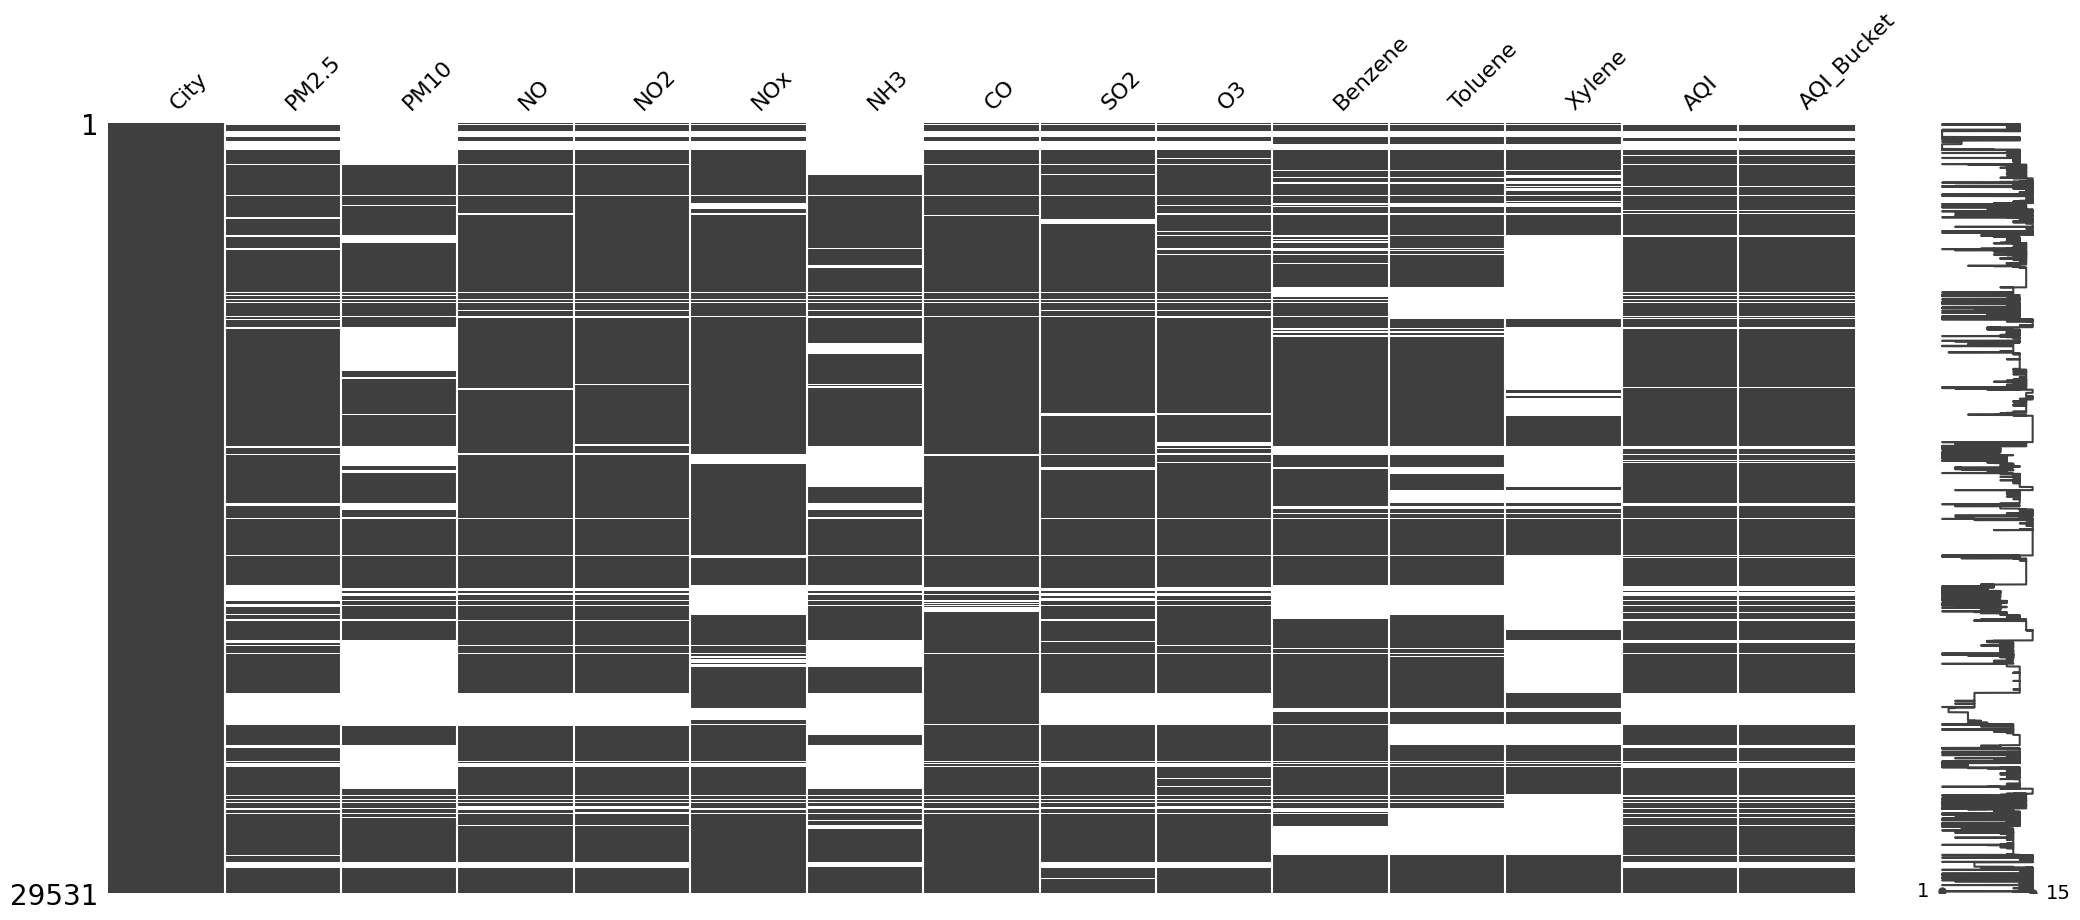

In [28]:
msno.matrix(city_day1)

# Missing Features

<Axes: >

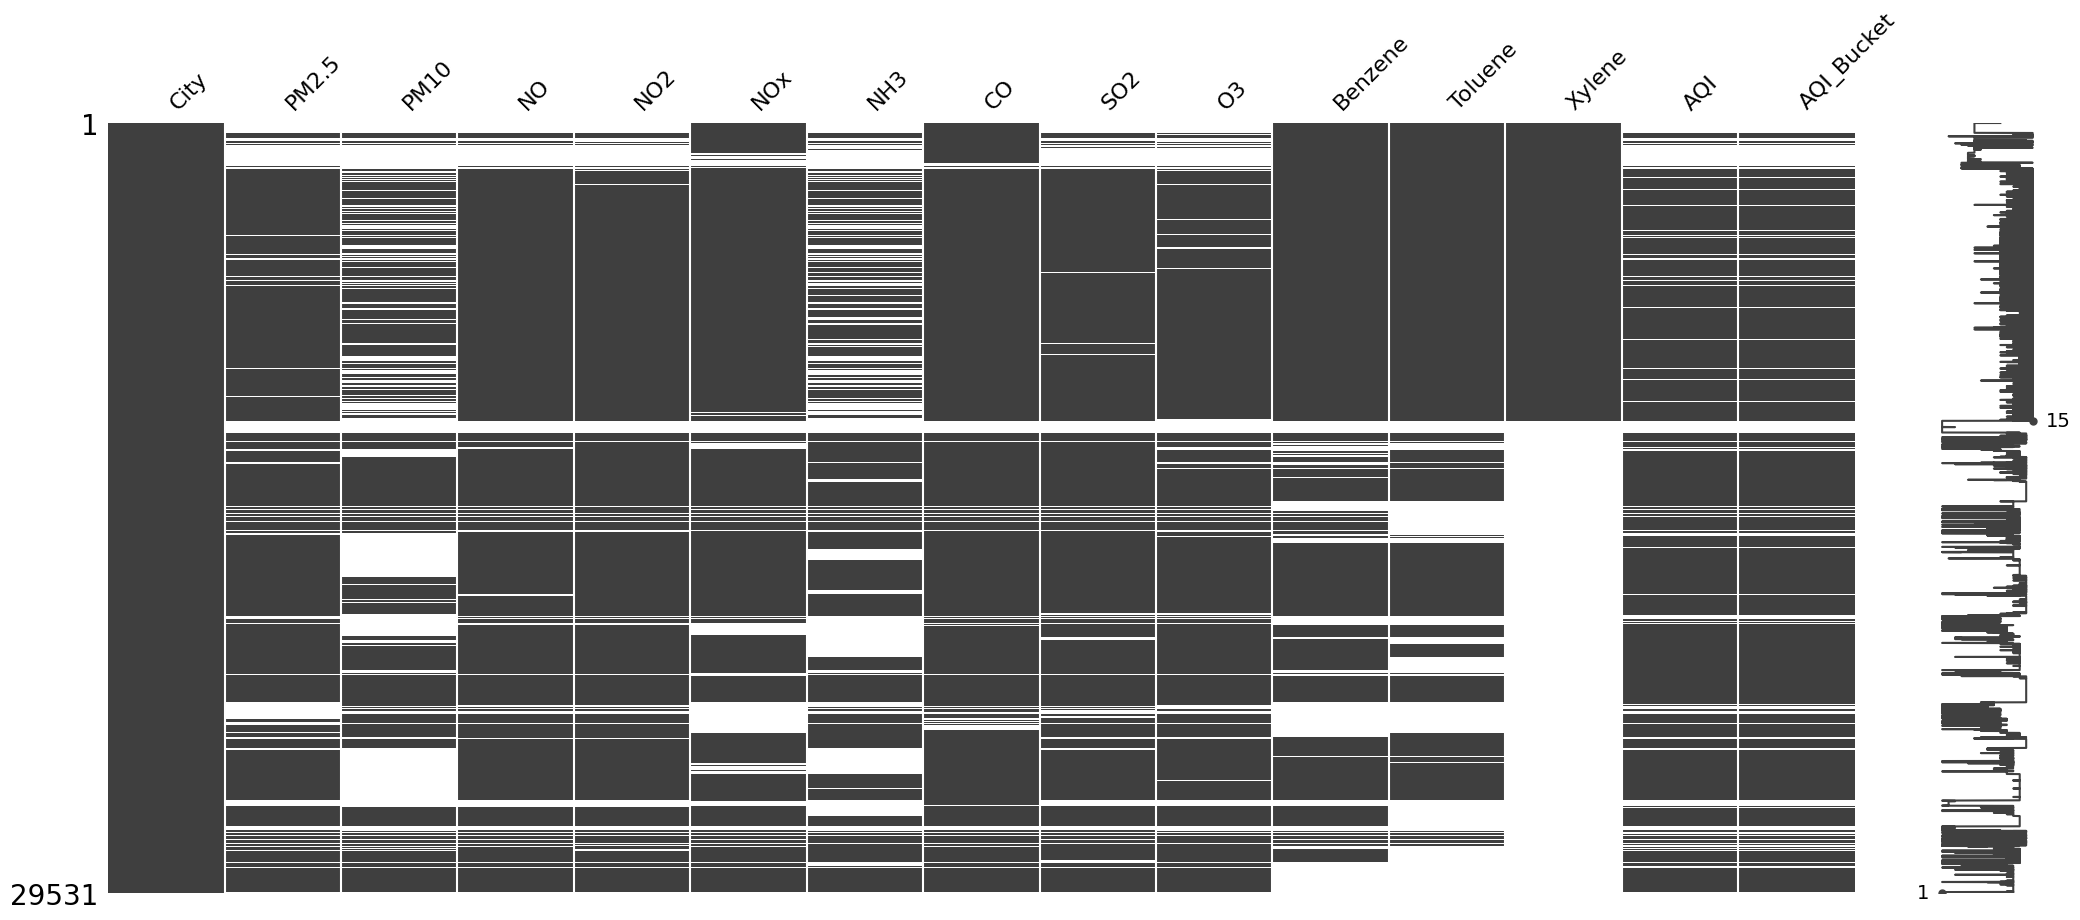

In [29]:
sorted_Xylene = city_day1.sort_values("Xylene")
msno.matrix(sorted_Xylene)

### Imputing using ffill

In [30]:
# Imputation using ffill/pad
# Imputing Xylene value

city_day['Xylene'][50:64]

Date
2015-02-20     7.48
2015-02-21    15.44
2015-02-22     8.47
2015-02-23    28.46
2015-02-24     6.05
2015-02-25     0.81
2015-02-26      NaN
2015-02-27      NaN
2015-02-28      NaN
2015-03-01     1.32
2015-03-02     0.22
2015-03-03     2.25
2015-03-04     1.55
2015-03-05     4.13
Name: Xylene, dtype: float64

In [31]:
city_day.fillna(method ='ffill', inplace=True)

In [32]:
city_day['Xylene'][50:64]

Date
2015-02-20     7.48
2015-02-21    15.44
2015-02-22     8.47
2015-02-23    28.46
2015-02-24     6.05
2015-02-25     0.81
2015-02-26     0.81
2015-02-27     0.81
2015-02-28     0.81
2015-03-01     1.32
2015-03-02     0.22
2015-03-03     2.25
2015-03-04     1.55
2015-03-05     4.13
Name: Xylene, dtype: float64

### Imputation of "AQI" using bfill

<Axes: >

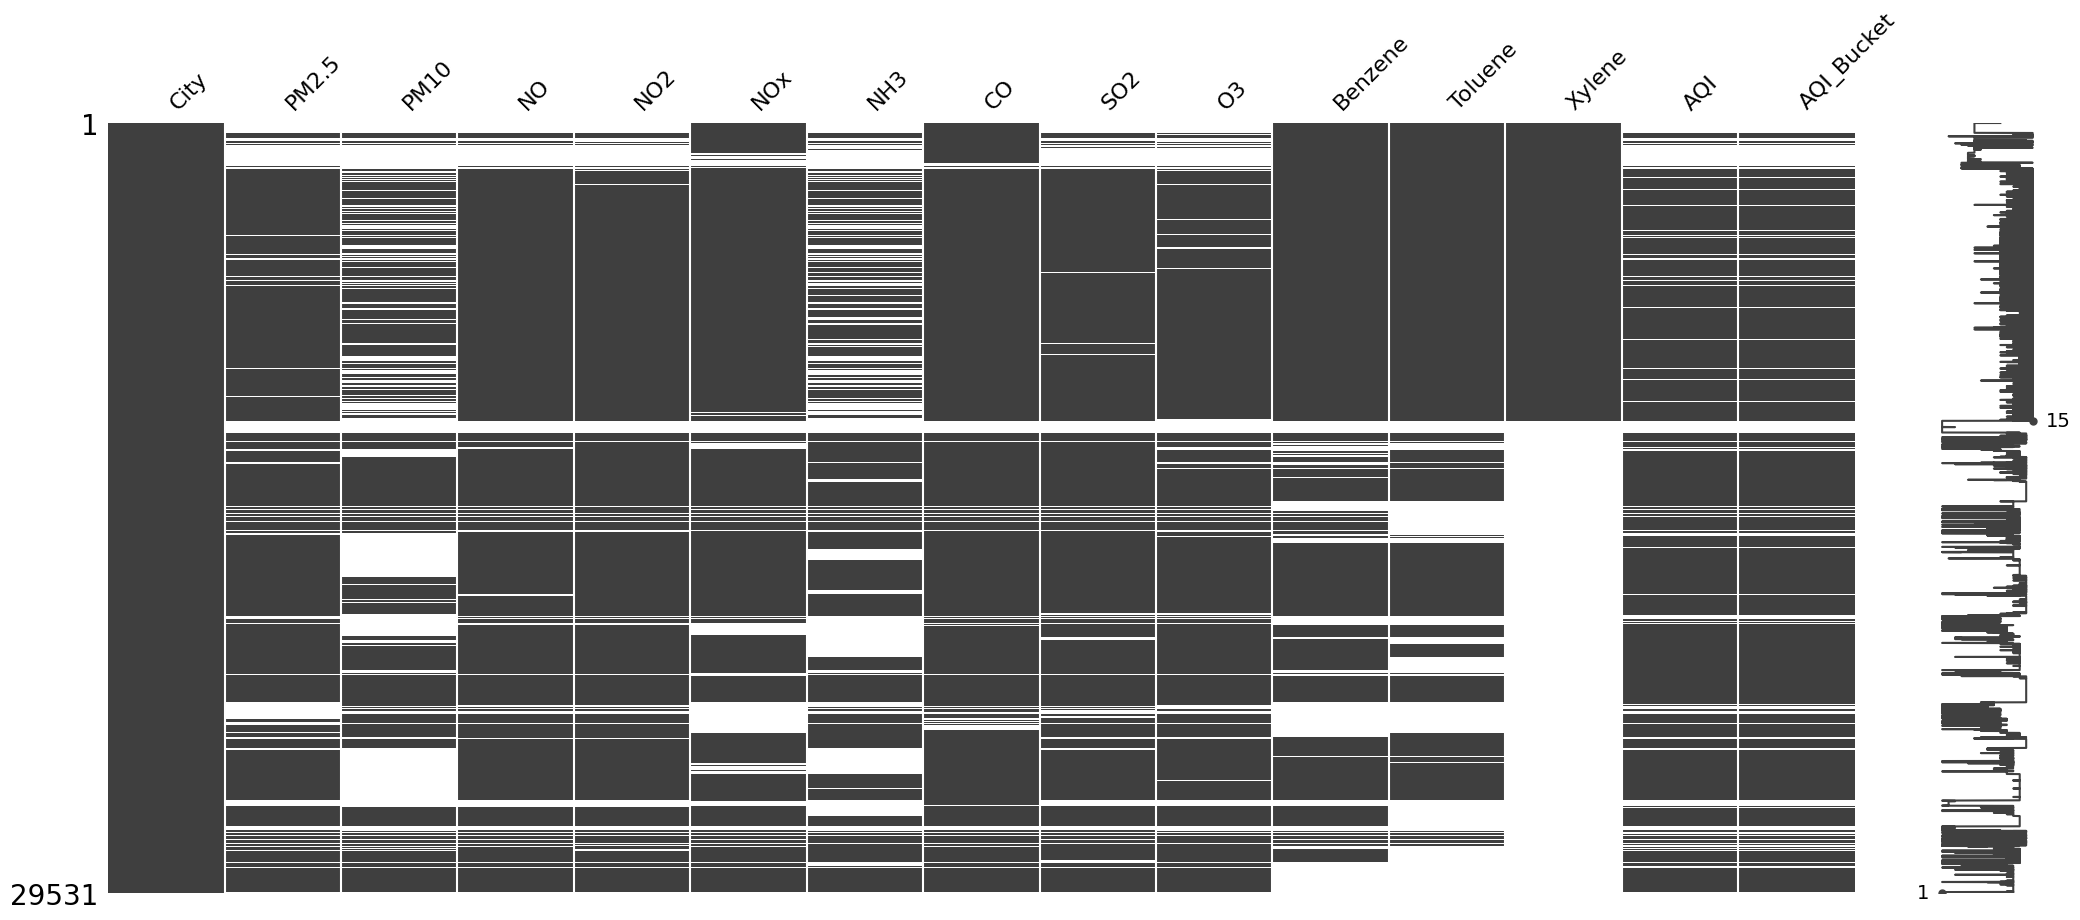

In [33]:
sorted_AQI = city_day1.sort_values("AQI")
msno.matrix(sorted_Xylene)

In [34]:
# Imputing AQI value

city_day['AQI'][20:30]

Date
2015-01-21      NaN
2015-01-22      NaN
2015-01-23      NaN
2015-01-24      NaN
2015-01-25      NaN
2015-01-26      NaN
2015-01-27      NaN
2015-01-28      NaN
2015-01-29    209.0
2015-01-30    328.0
Name: AQI, dtype: float64

In [35]:
city_day.fillna(method='bfill',inplace=True)
city_day['AQI'][20:30]

Date
2015-01-21    209.0
2015-01-22    209.0
2015-01-23    209.0
2015-01-24    209.0
2015-01-25    209.0
2015-01-26    209.0
2015-01-27    209.0
2015-01-28    209.0
2015-01-29    209.0
2015-01-30    328.0
Name: AQI, dtype: float64

# Imputation using Linear Interpolation method

Time series data has a lot of variations against time. Hence, imputing using backfill and forward fill isn't the ebst possible solution to address the missing value problem. A more apt alternative would be to use interpolation methods, where the values are filled with incrementing or decrementing values.

Linear interpolation is an imputation technique that assumes a linear relationship between data points and utilises non-missing values from adjacent data points to compute a value for a missing data point.

Refer to the official documentation for a complete list of interpolation strategies here

In [36]:
city_day1['Xylene'][50:65]

Date
2015-02-20     7.48
2015-02-21    15.44
2015-02-22     8.47
2015-02-23    28.46
2015-02-24     6.05
2015-02-25     0.81
2015-02-26      NaN
2015-02-27      NaN
2015-02-28      NaN
2015-03-01     1.32
2015-03-02     0.22
2015-03-03     2.25
2015-03-04     1.55
2015-03-05     4.13
2015-03-06      NaN
Name: Xylene, dtype: float64

In [37]:
# Interpolate using the linear method
city_day1.interpolate(limit_direction="both",inplace=True)

In [38]:
city_day1['Xylene'][50:65]

Date
2015-02-20     7.4800
2015-02-21    15.4400
2015-02-22     8.4700
2015-02-23    28.4600
2015-02-24     6.0500
2015-02-25     0.8100
2015-02-26     0.9375
2015-02-27     1.0650
2015-02-28     1.1925
2015-03-01     1.3200
2015-03-02     0.2200
2015-03-03     2.2500
2015-03-04     1.5500
2015-03-05     4.1300
2015-03-06     2.2600
Name: Xylene, dtype: float64

# Advanced Imputation Techniques
### 1. Nearest neighbors imputation.
### 2. Multivariate feature imputation

In [39]:
from sklearn.impute import KNNImputer

train_knn = train.copy(deep=True)

In [40]:
knn_imputer = KNNImputer(n_neighbors=2, weights="uniform")
train_knn['Age'] = knn_imputer.fit_transform(train_knn[['Age']])

In [41]:
train_knn['Age'].isnull().sum()

0

In [42]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
train_mice = train.copy(deep=True)

In [43]:
mice_imputer = IterativeImputer()
train_mice['Age'] = mice_imputer.fit_transform(train_mice[['Age']])

In [44]:
train_mice['Age'].isnull().sum()

0

# Sincerely, Mr. Eslam Fouad.